# Подключение к SQLite из Jupyter Notebook
# SQLite — это встроенная в Python база данных, не требующая установки. Для подключения в Jupyter Notebook используем модуль sqlite3


In [51]:
import pandas as pd 
import pandasql as ps
import sqlite3
import matplotlib.pyplot as plt

In [14]:
# путь до файла
file_path = '/home/neubauten2/Downloads/data.tsv'

# задаем в ручную названия столбов
df = pd.read_csv(file_path, sep='\t', header=None, names=['text', 'timestamp', 'platform'])

# переводим timestamp в дату
df["date"] = pd.to_datetime(df["timestamp"], unit="s")

# Создаём соединение с SQLite в памяти
conn = sqlite3.connect(":memory:")

In [15]:
# Записываем DataFrame в таблицу queries
df.to_sql("queries", conn, index=False, if_exists="replace")

# Посмотрим содержимое
query = """
SELECT text, date, platform
FROM queries
"""

df = pd.read_sql(query, conn) 
df.head(10)

,text,date,platform
0,малевич картины,2021-09-16 15:34:25,desktop
1,психология,2021-09-16 08:39:43,touch
2,с днём рождения лена,2021-09-16 05:52:43,touch
3,зверополис фильмы,2021-09-16 10:19:59,touch
4,алабай собака фото,2021-09-16 10:04:05,touch
5,бактериофаг,2021-09-16 18:16:42,desktop
6,полина гагарина,2021-09-16 14:53:25,touch
7,кадр из фильма,2021-09-16 05:40:37,desktop
8,погода,2021-09-16 08:25:41,touch
9,кухни дизайн,2021-09-16 17:37:01,touch


# Задание 1 — Диапазон дат¶

Необходимо определить, за какой период предоставлены данные. Для этого находим минимальную и максимальную дату в датасете data.tsv.

In [59]:
#Запрос на отбор дат + время
date_time = """
SELECT MIN(date) as min_date,
       MAX(date) as max_date
FROM queries
"""

#формируем датафрейм,
#если нужно только время, то оставляем первые 10 символов
df_1 = pd.read_sql(date_time, conn) 
first_task = f'Дата начала: {df_1.iloc[0, 0][:10]},  Дата конца: {df_1.iloc[0, 1][:10]}'

date_start = pd.to_datetime(df_1.iloc[0, 0][:10])
date_end = pd.to_datetime(df_1.iloc[0, 1][:10])
days_between = (date_end - date_start).days + 1
print(first_task)
print(f'Количество дней: {days_between}')
#но количество 2021-08-31 начинается с 21:00 когда малая активность, поэтому можем считать, что дней 21

Дата начала: 2021-08-31,  Дата конца: 2021-09-21
Количество дней: 22


In [26]:
#Запрос на отбор дат + время
date_time = """
SELECT MIN(date) as min_date,
       MAX(date) as max_date
FROM queries
"""

#формируем датафрейм,
#если нужно только время, то оставляем первые 10 символов
df_1 = pd.read_sql(date_time, conn) 
first_task = f'Дата начала: {df_1.iloc[0, 0][:10]},  Дата конца: {df_1.iloc[0, 1][:10]}'
print(first_task)


Дата начала: 2021-08-31,  Дата конца: 2021-09-21


# Задание 2 — Количество запросов с текстом "ютуб" по платформам

Фильтруем строки, где text содержит подстроку "ютуб" или "youtube", независимо от регистра
группируем по колонке platform и считаем количество запросов для каждой из них (desktop, touch).

Для более подробного анализа стоит воспользоваться нечетким поиском - fuzzy search.

In [39]:
#Запрос для отбора независимо от регистра имользуем функцию LOWER
youtube = """
SELECT platform,
       COUNT(*) as count
from queries
where LOWER(text) LIKE LOWER('%ютуб%') OR  LOWER(text) LIKE LOWER('%youtube%')
group by platform
"""

#формируем датафрейм,
df_2 = pd.read_sql(youtube, conn) 
display(df_2.style.hide(axis="index"))

platform,count
desktop,1651
touch,756


# Задание 3 — Топ‑10 самых частотных запросов в каждой платформе

Вывести 10 наиболее часто встречающихся запросов отдельно для desktop и touch.
Сравнить полученные списки и определить различие между ними.

In [46]:
#Запрос для отбора независимо от регистра имользуем функцию LOWER
top_10 = """
WITH AGGREGATE_QUERY AS (
SELECT platform,
       text,
       COUNT(*) as count
from queries
group by platform, LOWER(text)),

RANG_QUERY AS (
SELECT platform,
       text,
       count,
       rank() over (partition by platform order by count desc) as rk
from AGGREGATE_QUERY)

SELECT platform,
       text,
       count 
FROM RANG_QUERY
where rk <= 10
"""

#формируем датафрейм,
df_3 = pd.read_sql(top_10, conn) 
display(df_3.style.hide(axis="index"))

platform,text,count
desktop,календарь 2021,2804
desktop,таблица менделеева,2631
desktop,картинки,1647
desktop,английский алфавит,1293
desktop,обои на рабочий стол,1143
desktop,Одноклассники (социальная сеть),1116
desktop,таблица квадратов,877
desktop,алфавит,874
desktop,таблица умножения,867
desktop,youtube,838


# Задание 4 — Анализ трафика запросов в течение дня

Построить график запросов в течении дня и обьяснить различие в активности пользователей.

In [62]:
sutki = """
SELECT strftime('%H', date) as hour,
       COUNT(timestamp) / 21.0 as kolvo_zaprosov  -- делим на 21 (среднее за день)
FROM queries
WHERE date > '2021-08-31'  -- даты больше или равные 2021-08-31
GROUP BY hour
"""

sutki_zaprosy = pd.read_sql(sutki, conn)
display(sutki_zaprosy.style.hide(axis="index"))

hour,kolvo_zaprosov
00,438.809524
01,556.476190
02,777.714286
03,1247.047619
04,1830.380952
05,2597.714286
06,2934.857143
07,3042.761905
08,2822.714286
09,2881.190476


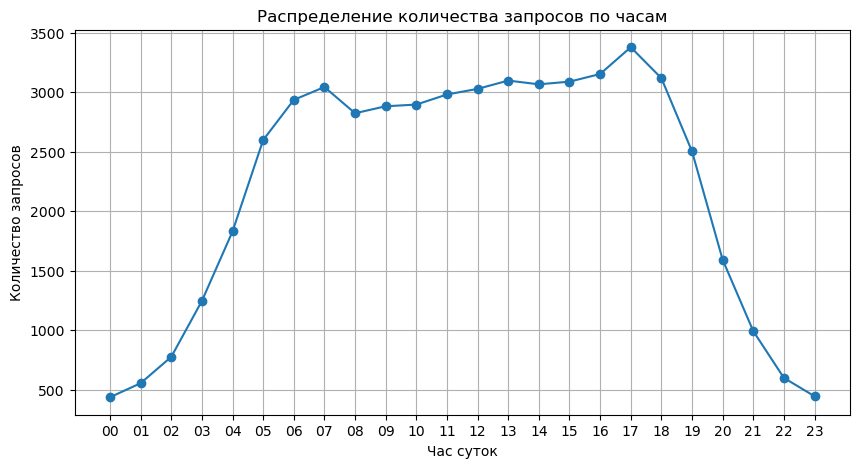

In [63]:
plt.figure(figsize=(10, 5))
plt.plot(sutki_zaprosy["hour"], sutki_zaprosy["kolvo_zaprosov"], marker="o")
plt.xlabel("Час суток")
plt.ylabel("Количество запросов")
plt.title("Распределение количества запросов по часам")
plt.grid(True)
plt.show()